<a href="https://colab.research.google.com/github/fabianandreslealbecerra-arch/Ciencia-de-datos/blob/main/Trabajando_con_medidas_centrales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AGENDA
1  trabajar dataframes

2  overview de los datos

3  ejercicios con medios centrales

4  analizar graficas






In [13]:
#para intalar librerias
! pip install statsmodels

In [14]:
!pip install wquantiles

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean #media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns # para graficas super bonitas
import matplotlib.pyplot as plt

In [16]:
estado=pd.read_csv("/content/state.csv")

In [17]:
#Ver cracteristicas de dataset
estado.head()#chismosear los 5 primeros archivos

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [18]:
estado.head(20)#chismosear los 5 primeros archivos

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


In [19]:
#CHISMOSEAR LOS ULTIMOS
estado.tail(3)

,State,Population,Murder.Rate,Abbreviation
47,West Virginia,1852994,4.0,WV
48,Wisconsin,5686986,2.9,WI
49,Wyoming,563626,2.7,WY


In [20]:
#registros aleatorios
estado.sample(7)

,State,Population,Murder.Rate,Abbreviation
36,Oregon,3831074,2.0,OR
2,Arizona,6392017,4.7,AZ
22,Minnesota,5303925,1.6,MN
21,Michigan,9883640,5.4,MI
42,Texas,25145561,4.4,TX
12,Illinois,12830632,5.3,IL
35,Oklahoma,3751351,4.5,OK


In [21]:
type(estado)

pandas.core.frame.DataFrame

##overview de los datos
analizando los diferentes datos presentes en el dataframe

In [22]:
#saber como se llama las diferentes columnas
estado.columns

Index(['State', 'Population', 'Murder.Rate', 'Abbreviation'], dtype='object')

In [23]:
#informacion general de dataframe
estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


In [24]:
#medidas de tendencia centrales estadisticas
estado.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


#estimar la tasa de poblacion y asesinatos

In [25]:
estado["Population"].mean()

np.float64(6162876.3)

In [26]:
trim_mean(estado.Population,0.1)

np.float64(4783697.125)

In [27]:
estado.Population.median()

4436369.5

In [28]:
estado["Murder.Rate"].mean()

np.float64(4.066)

In [29]:
trim_mean(estado["Murder.Rate"],0.1)

np.float64(3.9450000000000003)

In [30]:
estado["Murder.Rate"].median()

4.0

In [31]:
#media ponderada de tasa de asesinatos
np.average(estado['Murder.Rate'],weights=estado['Population'])

np.float64(4.445833981123393)

In [32]:
#mediana ponderada de tasa de asesinatos
wquantiles.median(estado.Population,weights=estado.Population)

np.float64(9660802.03629772)

Analizar graficas

<Axes: >

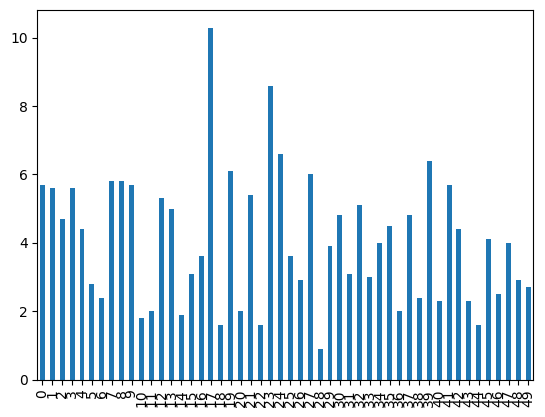

In [33]:
#graficar la tasa de asesinatos por estado
estado["Murder.Rate"].plot.bar()

<Axes: >

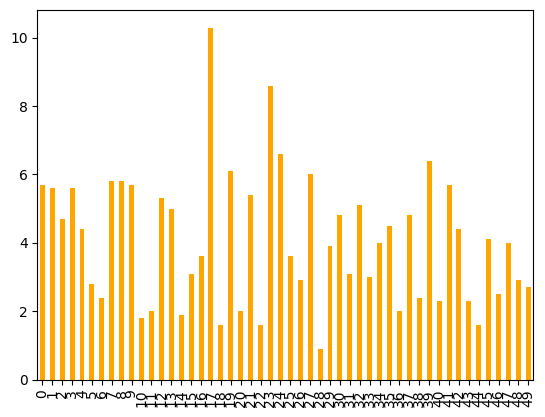

In [34]:
estado["Murder.Rate"].plot.bar(color="orange")

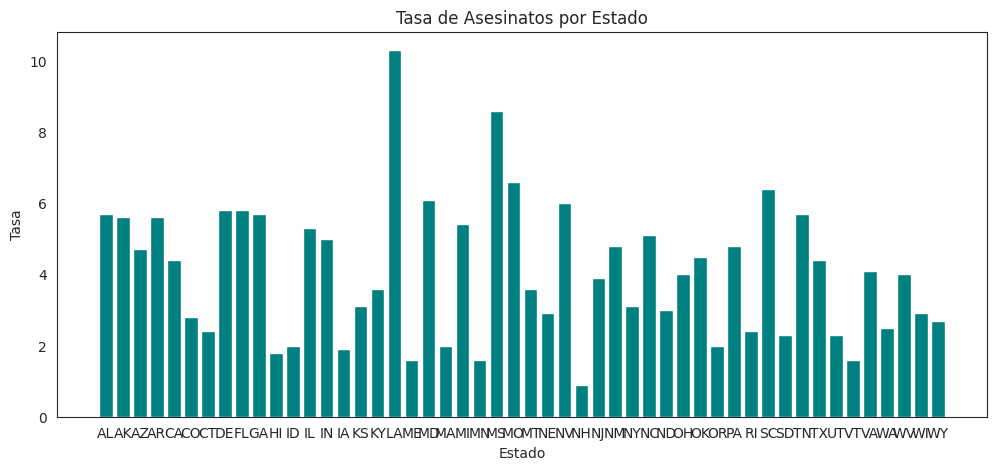

In [40]:
plt.figure(figsize=(12, 5))
plt.bar(estado["Abbreviation"], estado["Murder.Rate"], color="teal")

plt.title("Tasa de Asesinatos por Estado")
plt.xlabel("Estado")
plt.ylabel("Tasa")
plt.show()

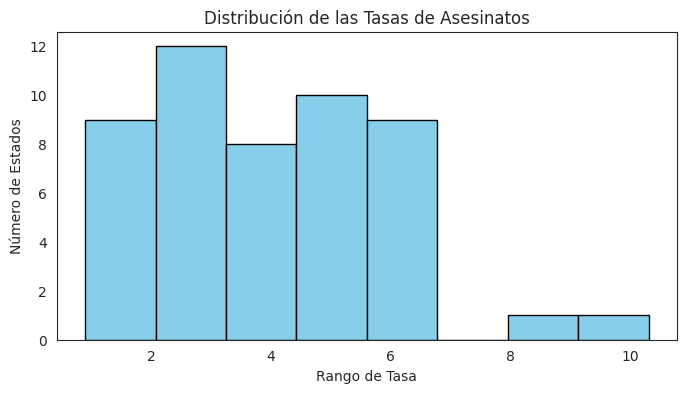

In [39]:
plt.figure(figsize=(8, 4))
plt.hist(estado["Murder.Rate"], bins=8, color="skyblue", edgecolor="black")

plt.title("Distribución de las Tasas de Asesinatos")
plt.xlabel("Rango de Tasa")
plt.ylabel("Número de Estados")
plt.show()

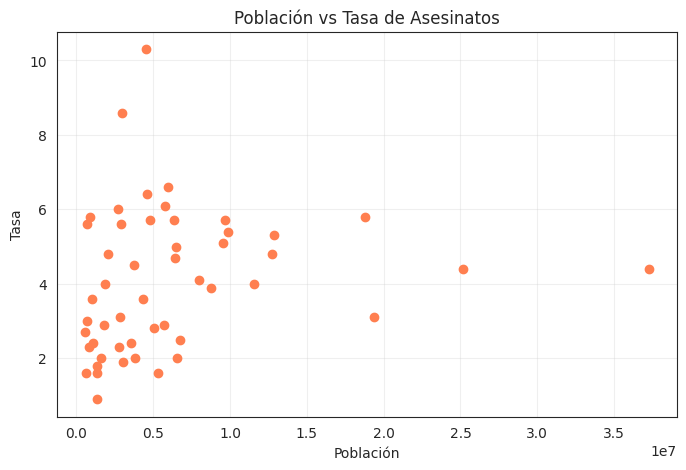

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(estado["Population"], estado["Murder.Rate"], color="coral")

plt.title("Población vs Tasa de Asesinatos")
plt.xlabel("Población")
plt.ylabel("Tasa")
plt.grid(True, alpha=0.3) # Una rejilla suave para que sea fácil de leer
plt.show()